In [1]:
!pip install nltk

In [1]:
#Dependcies
import pandas as pd
import re
from collections import Counter
from collections import Counter, defaultdict
from nltk.stem import WordNetLemmatizer
import nltk
import time
import math

nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Section A

In [2]:
#Data Load

train_data = pd.read_csv("../data/raw/wiki_train.csv").drop(columns=["title"])
validation_data = train_data.sample(n=100, random_state=58)
train_data = train_data.drop(validation_data.index)

In [4]:
#Preprocessing Pipeline
#Set up lemmatizer
#prepare re patterns to clean text (removed punctuation, fix extra space, and handle numbers)

lemmatizer = WordNetLemmatizer()

N_alpha = re.compile(r"[^a-z0-9\s]")

multi_space = re.compile(r"\s+")
numer_pat = re.compile(r'\d+([.,:/-]\d+)*')

year_pat = re.compile(r'\b(19|20)\d{2}\b')
per_pat = re.compile(r'\d+%')



In [5]:
#all the re pattern has been added

def preprocess(text, vocab=None):
    text = str(text).lower()
    text = numer_pat.sub(" num ", text)
    text = year_pat.sub(" year ", text)
    text = per_pat.sub(" percent ", text)
    text = text.encode("ascii", errors="ignore").decode()
    text = N_alpha.sub(" ", text)
    text = multi_space.sub(" ", text).strip()

    tokens = text.split()
    processed_tokens = []

    for w in tokens:
        lemma = lemmatizer.lemmatize(w)
        if len(lemma) > 1:
            processed_tokens.append(lemma)

    tokens = processed_tokens



    if vocab:
        updated_tokens = []

        for w in tokens:
            if vocab.get(w, 0) >= 2:
                updated_tokens.append(w)
            else:
                updated_tokens.append("<UNK>")

        tokens = updated_tokens


    return tokens


In [6]:
Start_A = time.time()

# Apply preprocessing
train_data["tokens"] = train_data["text"].apply(preprocess)

validation_data["tokens"] = validation_data["text"].apply(preprocess)

End_A=time.time()

print("time taken",End_A - Start_A)

time taken 137.3574914932251


In [7]:
# Build Vocabulary with min frequency=2
counter = Counter(w for doc in train_data["tokens"] for w in doc)

vocab = set()

for w, c in counter.items():
    if c >= 2:
        vocab.add(w)

vocab.update(["<UNK>"])

# Replace rare words with "<UNK>"
train_data["tokens"] = [[w if w in vocab else "<UNK>" for w in doc] for doc in train_data["tokens"]]

validation_data["tokens"] = [[w if w in vocab else "<UNK>" for w in doc] for doc in validation_data["tokens"]]


print("Final Vocabulary Size:", len(vocab))
print("Preprocessing Completed.")

Final Vocabulary Size: 194174
Preprocessing Completed.


Section B

In [8]:
start_B = time.time()

In [9]:
#adding the sentence starter and stopper at each sentences

def add_sentence_markers(docs):
    return [["<s>"] + doc + ["</s>"] for doc in docs]
train_docs = add_sentence_markers(train_data['tokens'].tolist())


#comouting document frequency of n-grams
from collections import defaultdict

def get_document_frequency(tokenized_articles, n):
    df = defaultdict(int)

    for article in tokenized_articles:
        seen_ngrams = set()
        for f in range(len(article) - n + 1):
            gram = tuple(article[f:f+n])

            seen_ngrams.add(gram)
        for gram in seen_ngrams:
            df[gram] += 1
    return df


# Building n-gram vocabulary and removing n-grams that doesnt appear in at least 1% of documents

def build_ngram_vocab(docs, n, min_doc_ratio=0.01): #(1%)
    doc_freq = defaultdict(int)
    total_docs = len(docs)
    for doc in docs:
        seen = set()
        for f in range(len(doc) - n + 1):
            ng = tuple(doc[f:f+n])
            seen.add(ng)
        for ng in seen:
            doc_freq[ng] += 1
    threshold = max(1, int(min_doc_ratio * total_docs))
    vocab = {ng for ng, df in doc_freq.items() if df >= threshold}
    return vocab

    # counting n-grams that are there in the vocabulary

def count_ngrams(docs, n, vocab):
    counts = Counter()
    for doc in docs:
        for f in range(len(doc) - n + 1):
            ng = tuple(doc[f:f+n])
            if ng in vocab:
                counts[ng] += 1
    return counts

In [10]:
# replacing out of vocab words with "<UNk>"
def replace_oov(docs, vocab):
    vocab_words = {ng[0] for ng in vocab}  # extract words from (word,) tuples
    new_docs = []

    for doc in docs:
        new_doc = []
        for word in doc:
            if word in vocab_words:
                new_doc.append(word)
            else:
                new_doc.append("<UNK>")
        new_docs.append(new_doc)

    return new_docs


In [11]:
from collections import Counter, defaultdict
#building uni gram model

uni_vocab = build_ngram_vocab(train_docs, n=1)

# Replace OOV words
train_docs = replace_oov(train_docs, uni_vocab)

# Add UNK to vocab
uni_vocab.add(("<UNK>",))

uni_counts = count_ngrams(train_docs, n=1, vocab=uni_vocab)


#building bi gram model

bi_vocab = build_ngram_vocab(train_docs, n=2)
bi_counts = count_ngrams(train_docs, n=2, vocab=bi_vocab)


# building tri gram model

tri_vocab = build_ngram_vocab(train_docs, n=3)
tri_counts = count_ngrams(train_docs, n=3, vocab=tri_vocab)

#vocab size of n-grams
print("Unigram vocab size:", len(uni_vocab))
print("Total unigram counts:", sum(uni_counts.values()))
print("Bigram vocab size:", len(bi_vocab))
print("Total bigram counts:", sum(bi_counts.values()))
print("Trigram vocab size:", len(tri_vocab))
print("Total trigram counts:", sum(tri_counts.values()))



Unigram vocab size: 8662
Total unigram counts: 32483748
Bigram vocab size: 20724
Total bigram counts: 19808691
Trigram vocab size: 12335
Total trigram counts: 7956799


Section B.1: MLE Estimation

Unigram MLE
 Formula :
 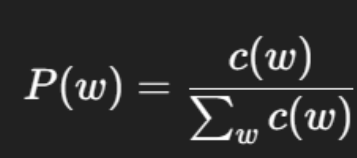

In [13]:
# fucntion for MLE for Unigram model

def unigram_mle(unigram_counts):
    total = sum(unigram_counts.values())
    probs = {}
    for w, c in unigram_counts.items():
        probs[w] = c / total
    return probs

uni_mle = unigram_mle(uni_counts)

Bigram MLE
 Formula :

 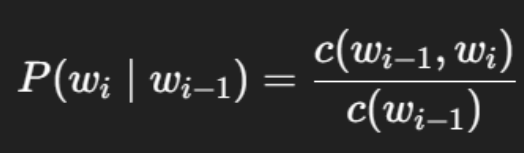

In [14]:
#fucntion for MLE for Bigram model

def bigram_mle(bigram_counts, unigram_counts):
    probs = {}
    for (w1, w2), c in bigram_counts.items():
        probs[(w1, w2)] = c / unigram_counts[(w1,)]
    return probs


bi_mle = bigram_mle(bi_counts, uni_counts)

Trigram MLE
Formula :

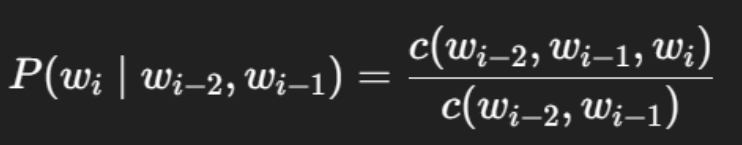

In [15]:
# fucntion for MLE for Trigram model

def trigram_mle(trigram_counts, bigram_counts):
    probs = {}
    for (w1, w2, w3), c in trigram_counts.items():
        probs[(w1, w2, w3)] = c / bigram_counts[(w1, w2)]
    return probs


tri_mle = trigram_mle(tri_counts, bi_counts)

Section B.2: Laplace Smoothing

In [16]:
# calculating V for the laplace smoothing and taking k = 1
V = len(uni_vocab)

Applying smoothing on the Unigram model

 Formula:

 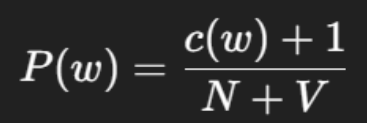

In [17]:

# function for laplace smoothing on the unigram model
def unigram_laplace(unigram_counts, vocab_size):
    total = sum(unigram_counts.values())
    probs = {}
    for w, c in unigram_counts.items():
        probs[w] = (c + 1) / (total + vocab_size)
    return probs

uni_laplace = unigram_laplace(uni_counts, V)

Bigram model
Formula:
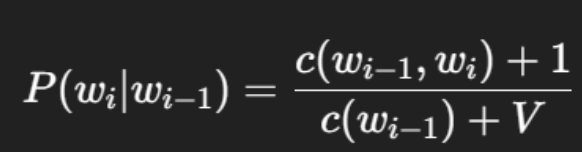

In [18]:
# function for laplace smoothing on the bigram model

def bigram_laplace(bigram_counts, unigram_counts, vocab_size):
    probs = {}
    for (w1, w2), c in bigram_counts.items():
        probs[(w1, w2)] = (c + 1) / (unigram_counts[(w1,)] + vocab_size)
    return probs

bi_laplace = bigram_laplace(bi_counts, uni_counts, V)

Trigram model
formula:
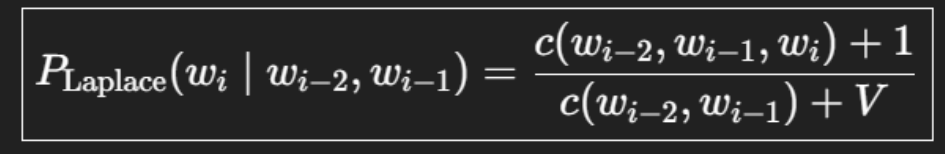

In [19]:
#  function for lapalace smoothing on the trigram model

def trigram_laplace(trigram_counts, bigram_counts, vocab_size):
    probs = {}
    for (w1, w2, w3), c in trigram_counts.items():
        probs[(w1, w2, w3)] = (c + 1) / (bigram_counts[(w1, w2)] + vocab_size)
    return probs

tri_laplace = trigram_laplace(tri_counts, bi_counts, V)



Section B.3: Good-Turing Smoothing

Good-Turing Adjusted count
Formula:

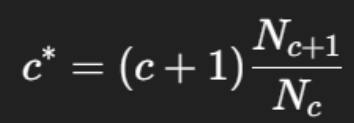

In [20]:
# Calculating the GT Adjusted count

def count_of_counts(counts):
    coc = Counter()
    for c in counts.values():
        coc[c] += 1
    return coc

Good-Turing Probability Estimation
Formula:

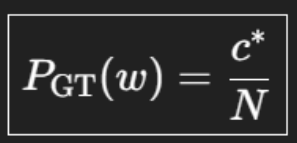
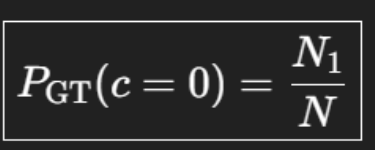

In [21]:
# function for probability estimation for unigram
def unigram_good_turing(unigram_counts):
    coc = count_of_counts(unigram_counts)
    total_tokens = sum(unigram_counts.values())

    probs = {}

    for w, c in unigram_counts.items():
        if (c + 1) in coc and c in coc:
            c_star = (c + 1) * (coc[c + 1] / coc[c])
        else:
            c_star = c
        probs[w] = c_star / total_tokens

    return probs


In [22]:
# function for probability estimation for Bigram
def bigram_good_turing(bigram_counts, unigram_counts):

    history_dict = defaultdict(dict)
    for (w1, w2), c in bigram_counts.items():
        history_dict[w1][(w1, w2)] = c

    probs = {}

    for w1 in history_dict:
        counts = history_dict[w1]
        coc = count_of_counts(counts)
        total_h = unigram_counts[(w1,)]

        for (w1, w2), c in counts.items():
            if (c + 1) in coc and c in coc:
                c_star = (c + 1) * (coc[c + 1] / coc[c])
            else:
                c_star = c

            probs[(w1, w2)] = c_star / total_h

    return probs


In [23]:
# function for probability estimation for trigram
def trigram_good_turing(trigram_counts, bigram_counts):

    history_dict = defaultdict(dict)

    for (w1, w2, w3), c in trigram_counts.items():
        history_dict[(w1, w2)][(w1, w2, w3)] = c

    probs = {}

    for history in history_dict:
        counts = history_dict[history]
        coc = count_of_counts(counts)
        total_h = bigram_counts[history]

        for (w1, w2, w3), c in counts.items():
            if (c + 1) in coc and c in coc:
                c_star = (c + 1) * (coc[c + 1] / coc[c])
            else:
                c_star = c

            probs[(w1, w2, w3)] = c_star / total_h

    return probs


In [24]:
# Compute Good–Turing adjusted prob. dist. for ngram models.


uni_gt = unigram_good_turing(uni_counts)
bi_gt = bigram_good_turing(bi_counts, uni_counts)
tri_gt = trigram_good_turing(tri_counts, bi_counts)


In [25]:
end_B = time.time()
print("Section B (Model building + estimation) time:", end_B - start_B, "seconds")


Section B (Model building + estimation) time: 170.1648805141449 seconds


In [26]:
start_C = time.time()

In [27]:
# since name of column is different in all 3 files, we are creating list for possible names

def get_text_column(df):
    possible_columns = ['text', 'abstract', 'Content']
    for col in possible_columns:
        if col in df.columns:
            return col

In [28]:
#Loading the test data set

wiki_test = pd.read_csv('../data/raw/wiki_test.csv')
arxiv_test = pd.read_csv('../data/raw/arxiv_test.csv')
finance_test = pd.read_csv('../data/raw/financial_test.csv')

In [29]:
#defining the function to prepare the test set into the required format
def prepare_test_docs(df, unigram_vocab):
    text_col = get_text_column(df)
    docs = df[text_col].apply(preprocess).tolist()
    docs = add_sentence_markers(docs)

    # Replace OOV words using training vocabulary
    vocab_words = {ng[0] for ng in unigram_vocab}

    new_docs = []
    for doc in docs:
        new_doc = []
        for word in doc:
            if word in vocab_words:
                new_doc.append(word)
            else:
                new_doc.append("<UNK>")
        new_docs.append(new_doc)

    return new_docs


In [30]:
# Applying the function to all the test sets
wiki_docs = prepare_test_docs(wiki_test, uni_vocab)
arxiv_docs = prepare_test_docs(arxiv_test, uni_vocab)
finance_docs = prepare_test_docs(finance_test, uni_vocab)

In [31]:
def get_unigram_prob(token, prob_dict, eps=1e-10):
    return prob_dict.get((token,), eps)


def get_bigram_prob(w1, w2, prob_dict, unigram_counts, V):
    if (w1, w2) in prob_dict:
        return prob_dict[(w1, w2)]
    else:
        return 1 / (unigram_counts.get((w1,), 0) + V)

def get_trigram_prob(w1, w2, w3, prob_dict, bigram_counts, V):
    if (w1, w2, w3) in prob_dict:
        return prob_dict[(w1, w2, w3)]
    else:
        return 1 / (bigram_counts.get((w1, w2), 0) + V)



In [32]:
def unigram_perplexity(docs, prob_dict):
    log_prob_sum = 0
    token_count = 0

    for doc in docs:
        for w in doc:
            p = get_unigram_prob(w, prob_dict)
            log_prob_sum += math.log(p)
            token_count += 1

    return math.exp(-log_prob_sum / token_count)

In [33]:
def bigram_perplexity(docs, prob_dict):
    log_prob_sum = 0
    token_count = 0

    for doc in docs:
        for i in range(1, len(doc)):
            p = get_bigram_prob(doc[i-1], doc[i], prob_dict, uni_counts, V)
            log_prob_sum += math.log(p)
            token_count += 1

    return math.exp(-log_prob_sum / token_count)


In [34]:
def trigram_perplexity(docs, prob_dict):
    log_prob_sum = 0
    token_count = 0

    for doc in docs:
        for i in range(2, len(doc)):
            p = get_trigram_prob(doc[i-2], doc[i-1], doc[i], prob_dict, bi_counts, V)
            log_prob_sum += math.log(p)
            token_count += 1

    return math.exp(-log_prob_sum / token_count)


In [35]:
results = {}

results['Laplace Unigram Wiki'] = unigram_perplexity(wiki_docs, uni_laplace)
results['Laplace Bigram Wiki'] = bigram_perplexity(wiki_docs, bi_laplace)
results['Laplace Trigram Wiki'] = trigram_perplexity(wiki_docs, tri_laplace)

results['Laplace Unigram Arxiv'] = unigram_perplexity(arxiv_docs, uni_laplace)
results['Laplace Bigram Arxiv'] = bigram_perplexity(arxiv_docs, bi_laplace)
results['Laplace Trigram Arxiv'] = trigram_perplexity(arxiv_docs, tri_laplace)

results['Laplace Unigram Finance'] = unigram_perplexity(finance_docs, uni_laplace)
results['Laplace Bigram Finance'] = bigram_perplexity(finance_docs, bi_laplace)
results['Laplace Trigram Finance'] = trigram_perplexity(finance_docs, tri_laplace)


In [36]:
results['GT Unigram Wiki'] = unigram_perplexity(wiki_docs, uni_gt)
results['GT Bigram Wiki'] = bigram_perplexity(wiki_docs, bi_gt)
results['GT Trigram Wiki'] = trigram_perplexity(wiki_docs, tri_gt)

results['GT Unigram Arxiv'] = unigram_perplexity(arxiv_docs, uni_gt)
results['GT Bigram Arxiv'] = bigram_perplexity(arxiv_docs, bi_gt)
results['GT Trigram Arxiv'] = trigram_perplexity(arxiv_docs, tri_gt)

results['GT Unigram Finance'] = unigram_perplexity(finance_docs, uni_gt)
results['GT Bigram Finance'] = bigram_perplexity(finance_docs, bi_gt)
results['GT Trigram Finance'] = trigram_perplexity(finance_docs, tri_gt)


In [37]:

for k, v in results.items():
    print(f"{k}: {v:.3f}")


Laplace Unigram Wiki: 538.411
Laplace Bigram Wiki: 666.219
Laplace Trigram Wiki: 2527.946
Laplace Unigram Arxiv: 496.321
Laplace Bigram Arxiv: 1390.687
Laplace Trigram Arxiv: 4124.343
Laplace Unigram Finance: 778.520
Laplace Bigram Finance: 1788.870
Laplace Trigram Finance: 5666.820
GT Unigram Wiki: 553.814
GT Bigram Wiki: 563.129
GT Trigram Wiki: 2036.327
GT Unigram Arxiv: 511.462
GT Bigram Arxiv: 1238.896
GT Trigram Arxiv: 3759.902
GT Unigram Finance: 809.299
GT Bigram Finance: 1589.676
GT Trigram Finance: 5230.520
